# Reading in simulated HGE footprint

These are sightlines simulated using the SYNTHPOP package: https://synthpop.readthedocs.io/en/latest/

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.axes import Axes
from matplotlib.image import AxesImage

#Yeah, this uses astropy instead of pandas, don't @ me
from astropy.table import Table, join
from astropy.table import vstack as tvstack
import astropy.units as u
from astropy.coordinates import SkyCoord

from scipy.stats import binned_statistic_2d, binned_statistic

import json
import glob

%matplotlib inline

def colorbar(ax: Axes, im: AxesImage):
    """
    Add a color bar aligned to `im` neater than `fig.colorbar(im)`.
    https://stackoverflow.com/a/39938019/8954109
    """

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.05)

    return ax.figure.colorbar(im, cax=cax, orientation="vertical")


# Get the data

This uses the GUMS underlying density model and the Marshall+ 3D extinction map: 
https://www.dropbox.com/scl/fo/5lw4ap0g92t2lt3m6ces8/AMvq3GK68X7SNPv64i5viLA?rlkey=gvnxw773qluplkm7nbq1v8smv&dl=0 

# Read & stack the data
If you just want a particular sightline, then don't stack.

<b>Note: These files have been scaled down in "counts" by a factor of 1000, as indicated in the filenames.</b> So if you're working with actual star counts, multiply everything by a factor of 1000. If you're just working with fractions or distribution shapes, you might not need to worry about that.

In [10]:
#Set the output_dir to wherever the data are
output_dir = './'
scale_factor = 1000.
files = np.array(glob.glob(output_dir+'hge*csv'))
n_files = len(files)
print('{} sightlines'.format(n_files))

for i_file, this_file in enumerate(files):
    dat0 = Table.read(this_file, format='csv')
    if i_file==0:
        dat = dat0
    else:
        dat = tvstack([dat,dat0])

#Reset longitudes to be symmetric around l=0
neg = (dat['l'] > 180.)
dat['l'][neg] = -1.*(360.-dat['l'][neg])

print('{} synthetic stars'.format(len(dat['pop'])))
print(dat.colnames)

189 sightlines
1278381 synthetic stars
['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J', '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5']


# Make some plots to visualize the points

In [64]:
#  If you see weird grid patterns, make your pixels larger. Damn round fields.
lon_rng = [min(dat['l']),max(dat['l'])]
delta_lon = 2.0 #deg
lon_nbins = round(abs(lon_rng[1]-lon_rng[0])/delta_lon)
lat_rng = [min(dat['b']),max(dat['b'])]
delta_lat = 0.75 #deg
lat_nbins = round(abs(lat_rng[1]-lat_rng[0])/delta_lat)
lb_pix_area = delta_lon*delta_lat #deg^2

xy_rng = [-15,15]
delta_xy = 1.0 #kpc
xy_nbins = round(abs(xy_rng[1]-xy_rng[0])/delta_xy)
xy_pix_area = delta_xy**2 #kpc^2
z_rng = [-5,5]
delta_z = 0.5 #kpc
z_nbins = round(abs(z_rng[1]-z_rng[0])/delta_z)
xz_pix_area = delta_xy*delta_z #kpc^2

#Let's assume we can remove foreground stars
gd = (dat['Dist'] > 5.0)

lb_n, xe, ye, bn = binned_statistic_2d(dat['l'][gd], dat['b'][gd], dat['l'][gd], statistic='count',
                                       range=[lon_rng,lat_rng], bins=[lon_nbins,lat_nbins])
lb_ak, xe, ye, bn = binned_statistic_2d(dat['l'][gd], dat['b'][gd], dat['A_Ks'][gd], statistic='median',
                                        range=[lon_rng,lat_rng], bins=[lon_nbins,lat_nbins])
xy_n, xe, ye, bn = binned_statistic_2d(dat['x'][gd], dat['y'][gd], dat['x'][gd], statistic='count',
                                       range=[xy_rng,xy_rng], bins=[xy_nbins,xy_nbins])
xy_mh, xe, ye, bn = binned_statistic_2d(dat['x'][gd], dat['y'][gd], dat['Fe/H_evolved'][gd], 
                                        statistic='median',
                                       range=[xy_rng,xy_rng], bins=[xy_nbins,xy_nbins])


/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_70467/1929970872.py:27: RuntimeWarning: divide by zero encountered in log10
  _=ax.imshow(np.log10(scale_factor*xy_n.T/xy_pix_area), origin='lower', aspect='auto',


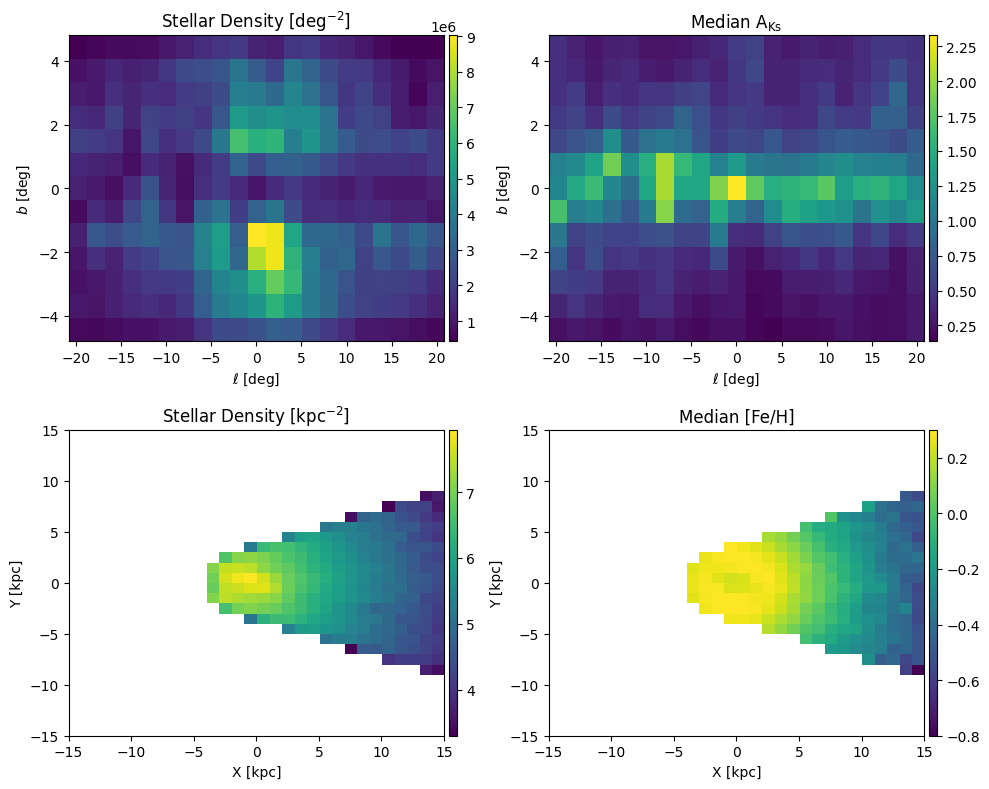

In [71]:
ax_pattern = """
             12
             34
             """
fig, axs = plt.subplot_mosaic(ax_pattern, figsize=(10,8))


ax = axs['1']
_=ax.imshow(scale_factor*lb_n.T/lb_pix_area, origin='lower', aspect='auto',
           extent=[min(lon_rng),max(lon_rng),min(lat_rng),max(lat_rng)],
           interpolation=None)
colorbar(ax, _)
ax.set_title(r'Stellar Density [deg$^{-2}$]')
ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel('$b$ [deg]')

ax = axs['2']
_=ax.imshow(lb_ak.T, origin='lower', aspect='auto',
           extent=[min(lon_rng),max(lon_rng),min(lat_rng),max(lat_rng)],
           interpolation=None)
colorbar(ax, _)
ax.set_title(r'Median A$_{\rm Ks}$')
ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel('$b$ [deg]')

ax = axs['3']
_=ax.imshow(np.log10(scale_factor*xy_n.T/xy_pix_area), origin='lower', aspect='auto',
            extent=[min(xy_rng),max(xy_rng),min(xy_rng),max(xy_rng)],
            interpolation=None)
colorbar(ax, _)
ax.set_title(r'Stellar Density [kpc$^{-2}$]')
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')

ax = axs['4']
_=ax.imshow(xy_mh.T, origin='lower', aspect='auto',
            extent=[min(xy_rng),max(xy_rng),min(xy_rng),max(xy_rng)],
            interpolation=None, vmin=-0.8, vmax=0.3)
colorbar(ax, _)
ax.set_title(r'Median [Fe/H]')
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')

fig.tight_layout()